# 🔍 Feature Importance & Entscheidungsbaum-Analyse

In diesem Abschnitt analysieren wir:
- die wichtigsten Einflussfaktoren (Feature Importances)
- stabile Permutations-Importance
- SHAP Feature Impact (falls verfügbar)
- den grafischen Entscheidungsbaum

Ziel:  
Herausfinden, *warum* der Baum ORSY-Kunden erkennt, und welche Variablen die größte Rolle spielen.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

In [2]:
# Daten laden
df = pd.read_csv("../data/dataset_wuerth.csv")

# ORSY-Flag korrekt setzen
df["flag_new_orsyshelf"] = (df["flag_new_orsyshelf"] > 0).astype(int)

# Mitarbeiter > 0
df = df[df["emp_count"] > 0]

# Feature-Auswahl (wie vorher definiert)
features = [
    "market_seg",
    "emp_count",
    "orders_count",
    "sales",
    "rev_salesrep",
    "rev_branch_office",
    "rev_ebusiness",
    "rev_internal_staff"
]

X = df[features].copy()
y = df["flag_new_orsyshelf"]

# Numerisch machen
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Modell trainieren
tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=50,
    random_state=42,
    class_weight="balanced"
)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


## 🌟 1. Klassische Feature Importance (Decision Tree)

Diese Importance zeigt, wie stark jede Variable die Splits des Baums beeinflusst.
Hohe Werte = wichtige Einflussfaktoren.

/var/folders/7w/3vw94kq12mbbs075sr0n34zr0000gp/T/ipykernel_20388/2453713869.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x="Importance", y="Feature", palette="viridis")


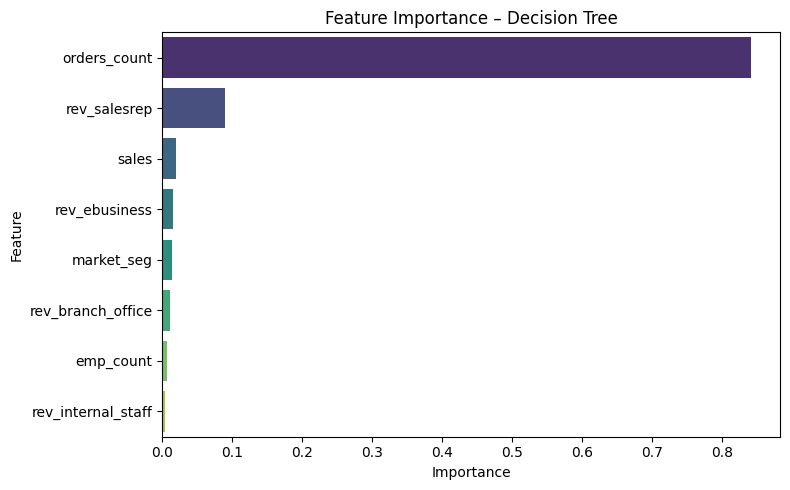

,Feature,Importance
2,orders_count,0.841048
4,rev_salesrep,0.089297
3,sales,0.019828
6,rev_ebusiness,0.014930
0,market_seg,0.013543
5,rev_branch_office,0.010706
1,emp_count,0.006497
7,rev_internal_staff,0.004150


In [3]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance – Decision Tree")
plt.tight_layout()
plt.show()

importance

## 🔁 2. Permutations-Importance

Diese Methode ist robuster, da sie misst, wie stark die Modellgüte sinkt,
wenn man ein Feature zufällig durchmischt.

➡️ Sehr guter Realitätscheck!

/var/folders/7w/3vw94kq12mbbs075sr0n34zr0000gp/T/ipykernel_20388/1853911003.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perm_imp, x="Importance_mean", y="Feature", palette="magma")


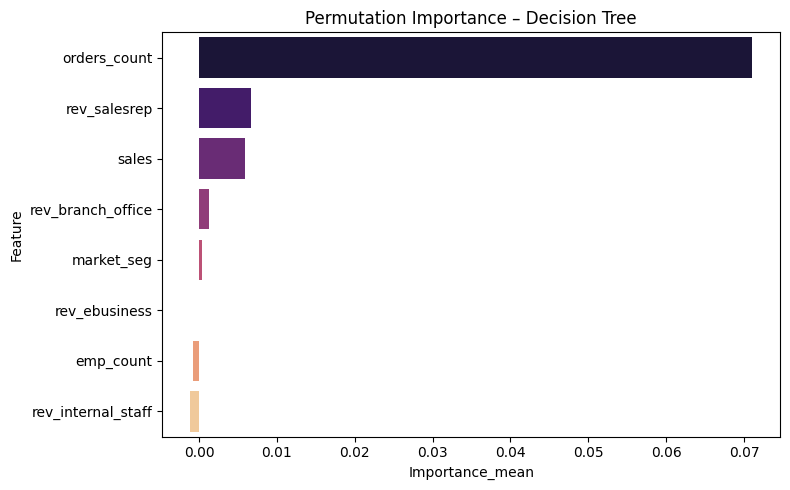

,Feature,Importance_mean,Importance_std
2,orders_count,0.071014,0.003940
4,rev_salesrep,0.006727,0.002183
3,sales,0.005938,0.001199
5,rev_branch_office,0.001321,0.001392
0,market_seg,0.000395,0.001386
6,rev_ebusiness,-0.000051,0.000783
1,emp_count,-0.000755,0.000605
7,rev_internal_staff,-0.001098,0.000487


In [4]:
perm = permutation_importance(
    tree, X_test, y_test, n_repeats=10, random_state=42
)

perm_imp = pd.DataFrame({
    "Feature": features,
    "Importance_mean": perm.importances_mean,
    "Importance_std": perm.importances_std
}).sort_values("Importance_mean", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=perm_imp, x="Importance_mean", y="Feature", palette="magma")
plt.title("Permutation Importance – Decision Tree")
plt.tight_layout()
plt.show()

perm_imp

## 🔮 3. SHAP Analyse (falls installiert)

SHAP erklärt den Einfluss jeder Variable *für jeden einzelnen Kunden*.

Wenn SHAP nicht installiert ist, überspringt das Notebook diesen Schritt automatisch.

In [5]:
try:
    import shap

    explainer = shap.TreeExplainer(tree)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(shap_values[1], X_test, plot_type="bar")
except Exception as e:
    print("⚠️ SHAP nicht verfügbar – Schritt wird übersprungen.")
    print("Grund:", e)

⚠️ SHAP nicht verfügbar – Schritt wird übersprungen.
Grund: No module named 'shap'


## 🌳 4. Entscheidungsbaum (vereinfachte Darstellung)

Wir plotten den Baum in einer kompakten Version (max_depth=4),
speichern ihn als PNG und zeigen ihn direkt im Notebook an.

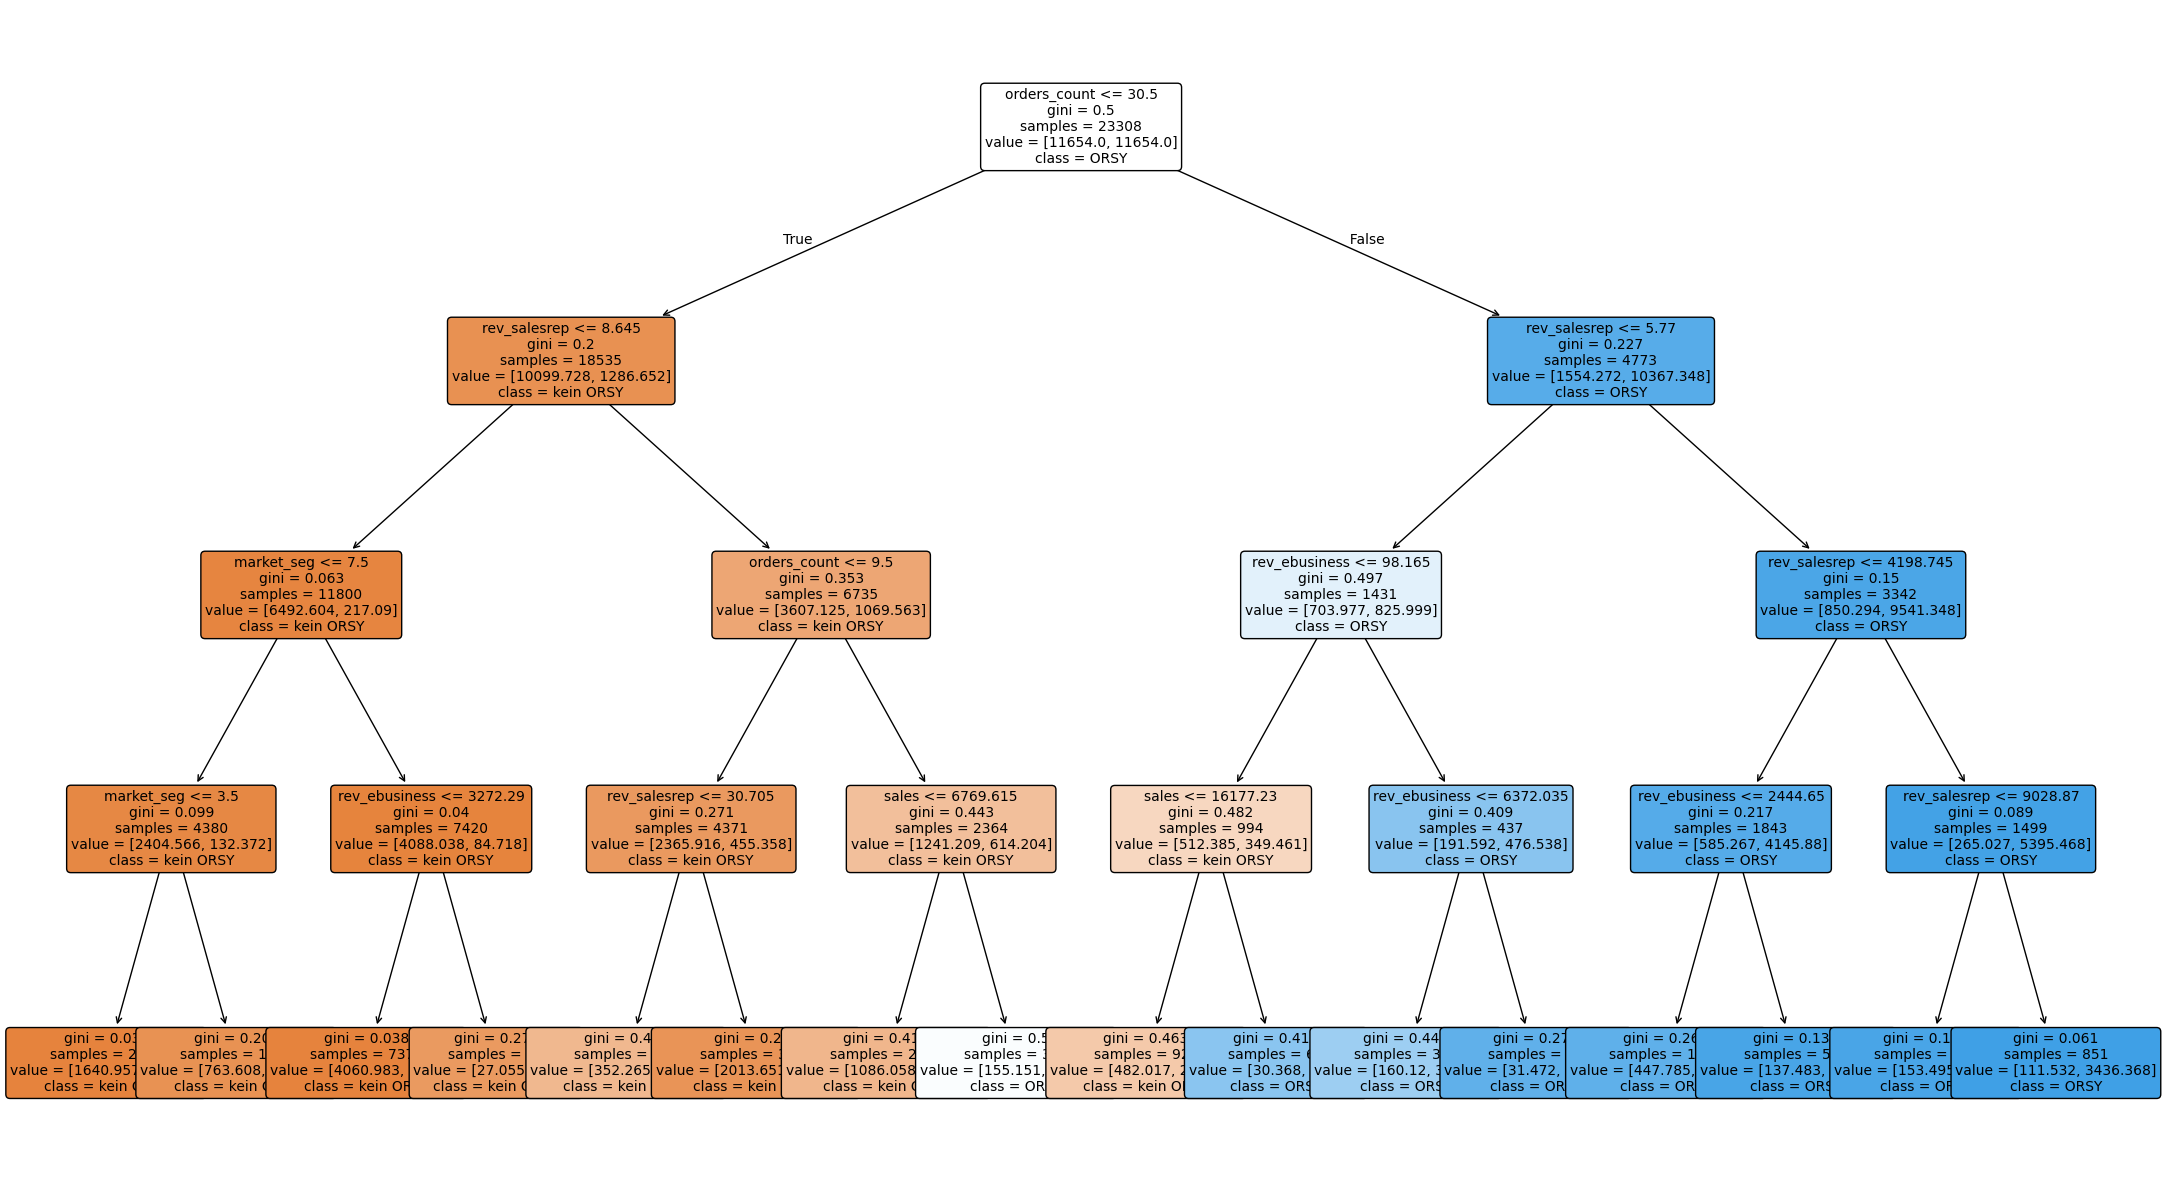

🌳 Entscheidungsbaum gespeichert unter: ../eda_plots/decision_tree.png


In [6]:
small_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=42,
    class_weight="balanced"
)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(22,12))
plot_tree(
    small_tree,
    feature_names=features,
    class_names=["kein ORSY", "ORSY"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.tight_layout()

out_path = "../eda_plots/decision_tree.png"
plt.savefig(out_path, dpi=150)
plt.show()

print("🌳 Entscheidungsbaum gespeichert unter:", out_path)